1. Importing Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Importing dataset

In [46]:
df = pd.read_csv("D:\Git-hub projects\sales-data-analysis\sales-data-analysis\data\sales.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
C:\Users\jdleo\AppData\Local\Temp\ipykernel_3680\1126265504.py:1: SyntaxWarning: invalid escape sequence '\G'
  df = pd.read_csv("D:\Git-hub projects\sales-data-analysis\sales-data-analysis\data\sales.csv")


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


3. Exploring the data

In [47]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


4. Cleaning the data

In [48]:
df.isnull().sum()
df = df.drop_duplicates()
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5


5. Checking totals

In [49]:
df["Calculated total"] = df["Quantity"] * df["Price per Unit"]

(df["Calculated total"] - df["Total Amount"]).sum() 

print(df["Calculated total"])

0       150
1      1000
2        30
3       500
4       100
       ... 
995      50
996      90
997     100
998     150
999     120
Name: Calculated total, Length: 1000, dtype: int64


6. Sales by product category

In [50]:
sales_category = df.groupby("Product Category")["Total Amount"].sum()

sales_category

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

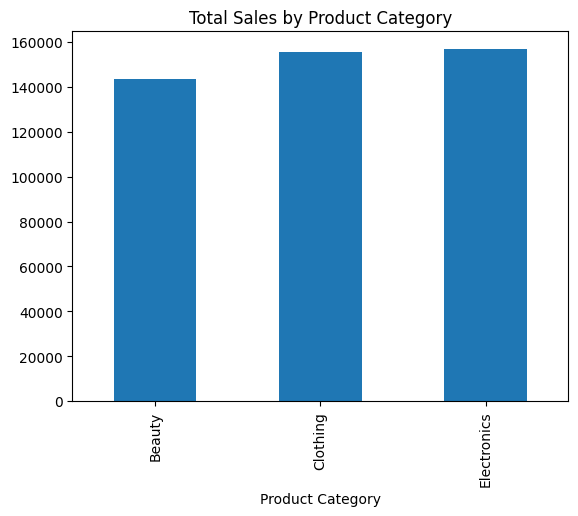

<Figure size 640x480 with 0 Axes>

In [51]:
sales_category.plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.show()
plt.savefig("D:\\Git-hub projects\\sales-data-analysis\\sales-data-analysis\\images\\sales_by_category.png")

7. Sales by Gender

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


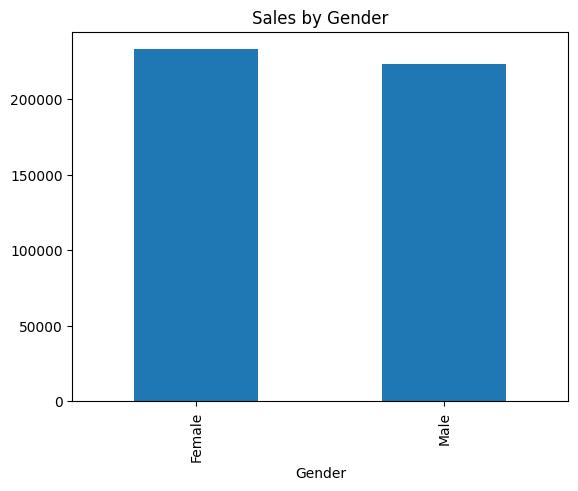

In [52]:
sales_gender = df.groupby("Gender")["Total Amount"].sum()
print(sales_gender)

sales_gender.plot(kind="bar")
plt.title("Sales by Gender")
plt.savefig("D:\\Git-hub projects\\sales-data-analysis\\sales-data-analysis\\images\\sales_by_gender.png")

8. Sales by Age

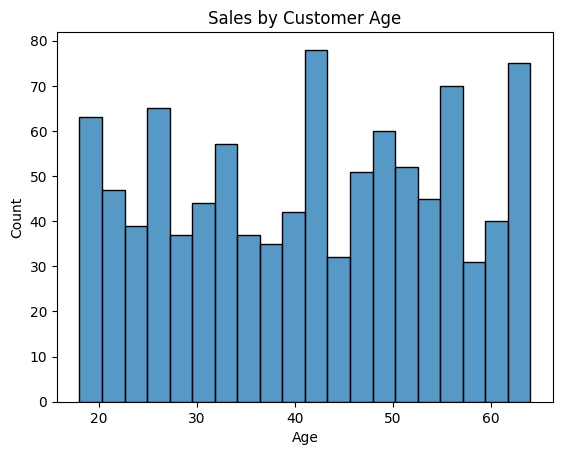

<Figure size 640x480 with 0 Axes>

In [53]:
sns.histplot(df["Age"], bins=20)
plt.title("Sales by Customer Age")
plt.show()
plt.savefig("D:\\Git-hub projects\\sales-data-analysis\\sales-data-analysis\\images\\sales_by_age.png")

9. Sales by Month

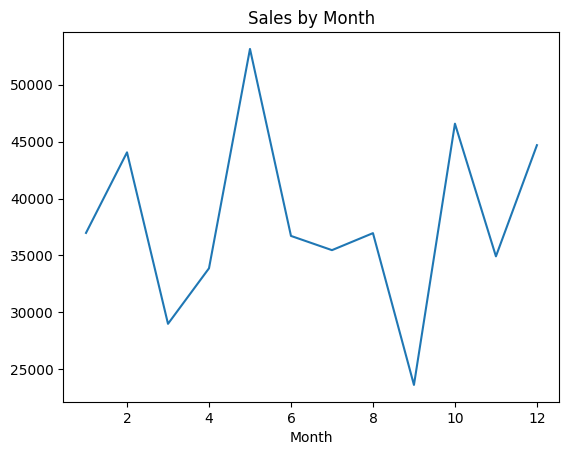

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64


<Figure size 640x480 with 0 Axes>

In [54]:
sales_month = df.groupby("Month")["Total Amount"].sum()

sales_month.plot()
plt.title("Sales by Month")
plt.show()
plt.savefig("D:\\Git-hub projects\\sales-data-analysis\\sales-data-analysis\\images\\sales_by_month.png")
print(sales_month)

10. Top 10 Customers

In [55]:
top_costumers = df.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False).head(10)
top_costumers

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64